# Logistic Regression

## Setu-Up

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
from transformers import AutoTokenizer
from preprocessing import Preprocessing
from datasets import CodeDataset
from torch.utils.data import DataLoader
from model import CodeBERTClassifier
from algorithms import FineTuningAlgorithm
from stop_criteria import CompositeStopCriteria, MaxEpochStopCriteria, MinLossStopCriteria
from labels import LABELS
import observers

device = Preprocessing.get_device()

/home/vscode/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data

In [3]:
examples = Preprocessing.load_examples("../dataset")
train_examples = examples

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")

train_dataset = CodeDataset(train_examples, tokenizer)
train_loader = DataLoader(train_dataset, shuffle=True)

[INFO] 50 exemplos carregados de '../dataset' (singleton: 10, factory: 10, observer: 10, strategy: 10, none: 10)


## Train

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 66375.07it/s]



  Iniciando treinamento

Época 1
  Treino  — Loss: 1.9903 | Acc: 0.1200

Época 2
  Treino  — Loss: 1.5198 | Acc: 0.3200

Época 3
  Treino  — Loss: 0.9736 | Acc: 0.5800

Época 4
  Treino  — Loss: 0.3409 | Acc: 0.9000

Época 5
  Treino  — Loss: 0.1231 | Acc: 0.9800

Época 6
  Treino  — Loss: 0.0889 | Acc: 0.9800


  Treinamento concluído



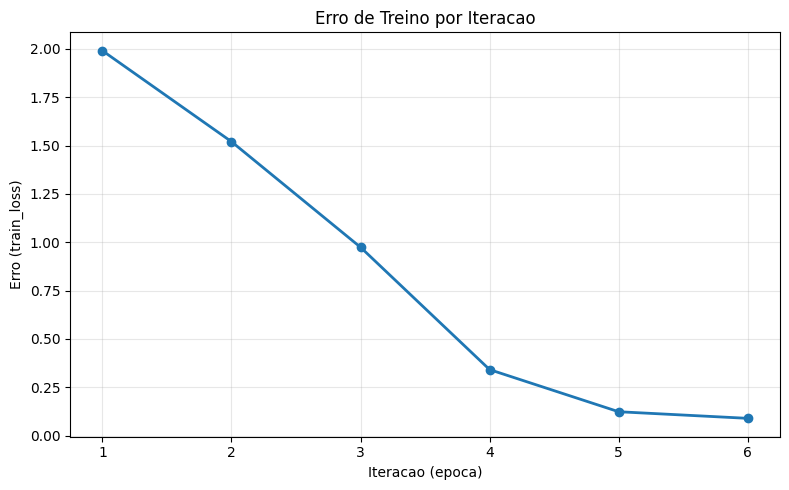

In [ ]:
model = CodeBERTClassifier(num_labels=len(LABELS)).to(device)

alg = FineTuningAlgorithm(
    model, train_loader, device, lr_encoder=1e-5, lr_classifier=1e-3
)

alg.add(observers.TrainingPrintObserver())

plotter = observers.PlotterAlgorithmsObserver()
alg.add(plotter)

composite_stop_criteria = CompositeStopCriteria()
composite_stop_criteria.add(MaxEpochStopCriteria(max_epoch=10))
composite_stop_criteria.add(MinLossStopCriteria(min_loss=0.1))

alg.fit(composite_stop_criteria)

plotter.plot()